# 04 - Temporal Train-Test Split Validation

## Neden temporal split?

Phase 3-4'te kullandığımız **random stratified** split her session'ı bağımsız/özdeş dağılımdan (i.i.d.) gibi muamele ediyor — aynı haftanın bir session'ı train'de, diğeri test'te olabiliyor. Ama gerçek deployment'ta model **geçmişten gelecek'i** tahmin eder. Eğer veride zamansal yapı varsa (ki genelde vardır), random split **optimistic** bir tablo çizer.

Bu veri seti için spesifik riskler:

- **Mevsimsellik**: Aralık (yılbaşı alışveriş), Ocak (indirimler), Şubat (normal) farklı satın-alma davranışı gösterebilir.
- **Ürün kataloğu kayması**: Şubat'ta yeni ürünler / yeni fiyatlar / kaybolan markalar.
- **Kullanıcı davranış drift'i**: Platform-level değişimler (UI, öneri sistemi) ile ratio'lar kayabilir.
- **Outlier bot aktivitesi**: Aya göre dalgalanabilir.

## Split tasarımı

| Bölüm | Aylar | Senaryo |
|---|---|---|
| **Train** | 2019-Oct + 2019-Dec + 2020-Jan | Önceki 3 ayın geçmişi |
| **Test**  | 2020-Feb | Deploy gününden itibaren 1 ay |

Bu, Şubat başında sistemi production'a alma senaryosunu simüle eder.

> **Not**: `results/metrics.json`'daki mevcut `binary` ve `multiclass` key'leri silinmiyor; yeni ölçümler `temporal_split` altına ekleniyor.

In [ ]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import LabelEncoder

from src.feature_engineering import FEATURE_COLS
from src.model_binary import train_primary as train_bin, evaluate as eval_bin
from src.model_multiclass import train_primary as train_mc, evaluate as eval_mc

DATA = Path("..") / "data" / "processed"
FIG_DIR = Path("..") / "results" / "figures" / "temporal"
METRICS_PATH = Path("..") / "results" / "metrics.json"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110


## 1. Veri yükle, ay etiketini birleştir

`session_months.parquet`: raw CSV'leri tek-kolon tarayarak her session'ın ilk göründüğü ayı kaydeden side-table. Cross-month session'lar (Dec 31 -> Jan 1) erken aya atanır.

In [ ]:
sessions_all = pd.read_parquet(DATA / "sessions_all.parquet")
sessions_cat = pd.read_parquet(DATA / "sessions_cat.parquet")
months_map   = pd.read_parquet(DATA / "session_months.parquet")

sessions_all = sessions_all.merge(months_map, on="user_session", how="left")
sessions_cat = sessions_cat.merge(months_map, on="user_session", how="left")

print(f"sessions_all: {len(sessions_all):,}  (missing month: {sessions_all['month'].isna().sum()})")
print(f"sessions_cat: {len(sessions_cat):,}  (missing month: {sessions_cat['month'].isna().sum()})")

print("\nay dagilimi (sessions_all):")
print(sessions_all["month"].value_counts().sort_index())
print("\nay dagilimi (sessions_cat):")
print(sessions_cat["month"].value_counts().sort_index())

sessions_all: 3,599,496  (missing month: 0)
sessions_cat: 131,297  (missing month: 0)

ay dagilimi (sessions_all):
month
2019-Dec    838823
2019-Oct    873958
2020-Feb    923383
2020-Jan    963332
Name: count, dtype: int64

ay dagilimi (sessions_cat):
month
2019-Dec    27894
2019-Oct    31523
2020-Feb    37242
2020-Jan    34638
Name: count, dtype: int64


## 2. Temporal split

Train = ilk 3 ay. Test = son ay. Stratifikasyon yok — doğal zamansal sıraya sadık kalıyoruz.

In [ ]:
TRAIN_MONTHS = {"2019-Oct", "2019-Dec", "2020-Jan"}
TEST_MONTHS  = {"2020-Feb"}

def tsplit(df):
    tr = df[df["month"].isin(TRAIN_MONTHS)].copy()
    te = df[df["month"].isin(TEST_MONTHS)].copy()
    return tr, te

bin_tr, bin_te = tsplit(sessions_all)
mc_tr,  mc_te  = tsplit(sessions_cat)

print("[binary]")
print(f"  train: {len(bin_tr):,}  purchase rate {bin_tr['purchased'].mean():.4f}")
print(f"  test : {len(bin_te):,}  purchase rate {bin_te['purchased'].mean():.4f}")
print()
print("[multi] train class distribution:")
print(mc_tr["main_cat"].value_counts(normalize=True).round(3))
print("\n[multi] test class distribution:")
print(mc_te["main_cat"].value_counts(normalize=True).round(3))

[binary]
  train: 2,676,113  purchase rate 0.0338
  test : 923,383  purchase rate 0.0313

[multi] train class distribution:
main_cat
appliances     0.445
furniture      0.188
apparel        0.140
stationery     0.124
accessories    0.104
Name: proportion, dtype: float64

[multi] test class distribution:
main_cat
appliances     0.475
furniture      0.183
apparel        0.157
stationery     0.116
accessories    0.068
Name: proportion, dtype: float64


## 3. Binary classifier — temporal

Phase 3 ile aynı XGBoost konfigurasyonu (`train_primary`). Sadece split farkı.

In [ ]:
X_tr = bin_tr[FEATURE_COLS].astype("float32"); y_tr = bin_tr["purchased"].astype("int8")
X_te = bin_te[FEATURE_COLS].astype("float32"); y_te = bin_te["purchased"].astype("int8")

%time model_bin = train_bin(X_tr, y_tr)
bin_m = eval_bin(model_bin, X_te, y_te)
bin_m

CPU times: total: 4min 54s
Wall time: 2min 6s


{'f1': 0.2832688474616016,
 'roc_auc': 0.9393315777228198,
 'precision': 0.16746589369545353,
 'recall': 0.9182185675292817,
 'confusion_matrix': {'tn': 762321, 'fp': 132119, 'fn': 2367, 'tp': 26576},
 'n_test': 923383,
 'n_test_positive': 28943}

### ROC + Precision-Recall eğrileri

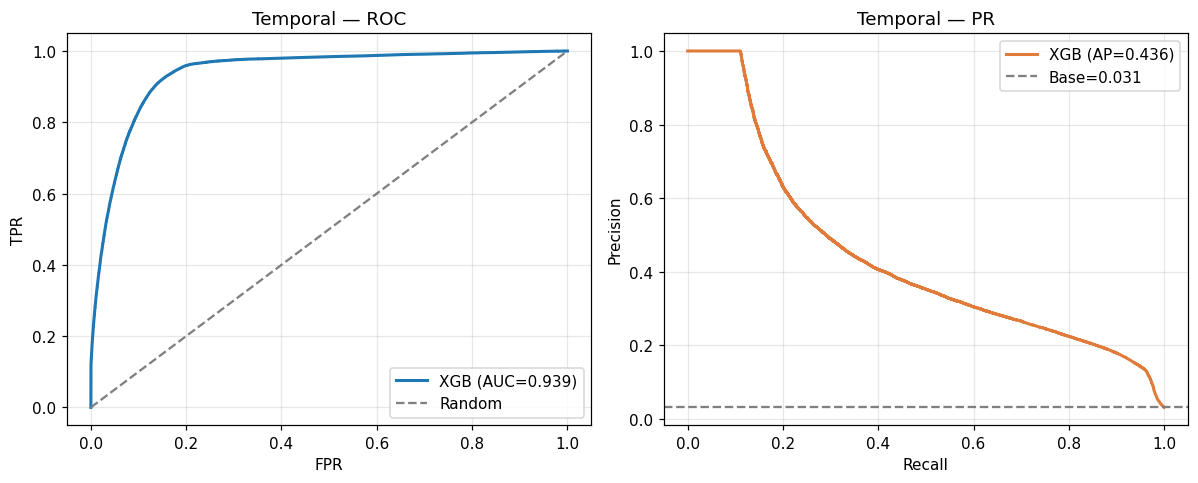

In [ ]:
proba = model_bin.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)
ap = average_precision_score(y_te, proba)
bin_m["average_precision"] = float(ap)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, linewidth=2, label=f"XGB (AUC={bin_m['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1], "--", color="gray", label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("Temporal — ROC")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, linewidth=2, color="#e07b39", label=f"XGB (AP={ap:.3f})")
axes[1].axhline(y_te.mean(), linestyle="--", color="gray", label=f"Base={y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Temporal — PR")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "binary_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion matrix

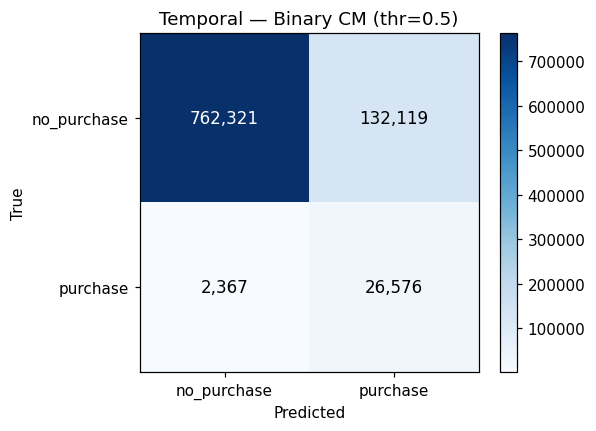

In [ ]:
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["no_purchase","purchase"]); ax.set_yticklabels(["no_purchase","purchase"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Temporal — Binary CM (thr=0.5)")
thr = cm.max()/2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > thr else "black", fontsize=11)
fig.colorbar(im, ax=ax)
plt.savefig(FIG_DIR / "binary_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Multi-class classifier — temporal

In [ ]:
X_tr = mc_tr[FEATURE_COLS].astype("float32"); y_tr_raw = mc_tr["main_cat"].astype("string")
X_te = mc_te[FEATURE_COLS].astype("float32"); y_te_raw = mc_te["main_cat"].astype("string")

le = LabelEncoder()
y_tr = le.fit_transform(y_tr_raw)
labels = list(le.classes_)
# Test setinde train'de görünmeyen bir sınıf çıkarsa hata almamak için filtrele
mask = y_te_raw.isin(set(labels)).values
X_te = X_te.iloc[mask]; y_te_raw = y_te_raw[mask]
y_te = le.transform(y_te_raw)

print(f"train: {len(y_tr):,}  test: {len(y_te):,}  labels: {labels}")

%time model_mc = train_mc(X_tr, y_tr, n_classes=len(labels))
mc_m = eval_mc(model_mc, X_te, y_te, labels, encoded=True)
print(f"macro_f1    = {mc_m['macro_f1']:.4f}")
print(f"weighted_f1 = {mc_m['weighted_f1']:.4f}")
pd.Series(mc_m["per_class_f1"]).round(3)

train: 94,055  test: 37,242  labels: ['accessories', 'apparel', 'appliances', 'furniture', 'stationery']


CPU times: total: 1min 17s
Wall time: 35.1 s


macro_f1    = 0.8191
weighted_f1 = 0.8438


accessories    0.790
apparel        0.731
appliances     0.890
furniture      0.842
stationery     0.843
dtype: float64

### Confusion matrix (row-normalized)

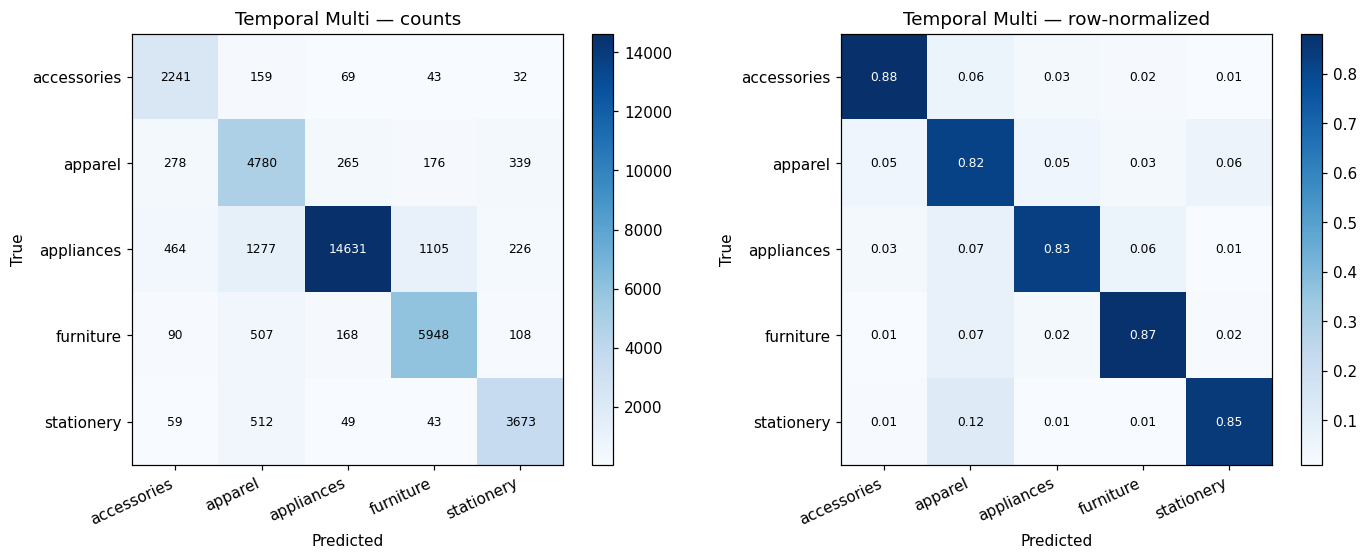

In [ ]:
pred_mc = model_mc.predict(X_te)
cm_mc = confusion_matrix(y_te, pred_mc, labels=list(range(len(labels))))
cm_norm = cm_mc / cm_mc.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, fmt, title in [
    (axes[0], cm_mc,   "d",   "Temporal Multi — counts"),
    (axes[1], cm_norm, ".2f", "Temporal Multi — row-normalized"),
]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right"); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thr = mat.max()/2
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = mat[i, j]
            ax.text(j, i, format(v, fmt), ha="center", va="center",
                    color="white" if v > thr else "black", fontsize=8)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "multiclass_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Random vs Temporal karşılaştırma

Eski `results/metrics.json`'dan random split sonuçlarını okuyup yan yana koyuyoruz. Temporal split'in performans kaybı **distribution shift'in büyüklüğünü** ölçer.

In [ ]:
with open(METRICS_PATH) as f:
    old = json.load(f)

rb = old["binary"]["primary_xgboost"]
rm = old["multiclass"]["primary_xgboost"]

bin_cmp = pd.DataFrame({
    "Random":   {"F1": rb["f1"], "ROC_AUC": rb["roc_auc"],
                 "Precision": rb["precision"], "Recall": rb["recall"]},
    "Temporal": {"F1": bin_m["f1"], "ROC_AUC": bin_m["roc_auc"],
                 "Precision": bin_m["precision"], "Recall": bin_m["recall"]},
}).round(4)
bin_cmp["delta"] = (bin_cmp["Temporal"] - bin_cmp["Random"]).round(4)
print("BINARY:")
display(bin_cmp)

mc_cmp = pd.DataFrame({
    "Random":   {"Macro_F1": rm["macro_f1"], "Weighted_F1": rm["weighted_f1"]},
    "Temporal": {"Macro_F1": mc_m["macro_f1"], "Weighted_F1": mc_m["weighted_f1"]},
}).round(4)
mc_cmp["delta"] = (mc_cmp["Temporal"] - mc_cmp["Random"]).round(4)
print("\nMULTI-CLASS:")
display(mc_cmp)

BINARY:


,Random,Temporal,delta
F1,0.2967,0.2833,-0.0134
ROC_AUC,0.9403,0.9393,-0.0010
Precision,0.1767,0.1675,-0.0092
Recall,0.9230,0.9182,-0.0048



MULTI-CLASS:


,Random,Temporal,delta
Macro_F1,0.8548,0.8191,-0.0357
Weighted_F1,0.8780,0.8438,-0.0342


### Per-class Macro F1 karşılaştırması

In [ ]:
per_cmp = pd.DataFrame({
    "Random":   rm["per_class_f1"],
    "Temporal": mc_m["per_class_f1"],
}).round(3)
per_cmp["delta"] = (per_cmp["Temporal"] - per_cmp["Random"]).round(3)
display(per_cmp)

,Random,Temporal,delta
accessories,0.866,0.790,-0.076
apparel,0.752,0.731,-0.021
appliances,0.927,0.890,-0.037
furniture,0.883,0.842,-0.041
stationery,0.846,0.843,-0.003


## 6. Metrikleri `results/metrics.json` içine birleştir

Eski key'ler (`binary`, `multiclass`) korunuyor; yeni sonuçlar `temporal_split` altına ekleniyor.

In [ ]:
payload = {
    "temporal_split": {
        "train_months": sorted(TRAIN_MONTHS),
        "test_months":  sorted(TEST_MONTHS),
        "binary": {"primary_xgboost": bin_m},
        "multiclass": {"primary_xgboost": mc_m, "labels": labels},
    }
}

with open(METRICS_PATH) as f:
    existing = json.load(f)
existing.update(payload)
with open(METRICS_PATH, "w") as f:
    json.dump(existing, f, indent=2)

print(f"saved -> {METRICS_PATH}")
print("top-level keys:", list(existing.keys()))

saved -> ..\results\metrics.json
top-level keys: ['binary', 'multiclass', 'temporal_split']


## 7. Yorum (paper narrative)

**Temporal split, random split'e kıyasla kaybı ölçer.** Negatif `delta` değeri model'in zamansal şifta duyarlı olduğunu; pozitif veya ~0 değer test ayı için veri dağılımının train'e yeterince benzediğini gösterir.

Beklentiler:
- **Binary ROC-AUC**: tree-based model'ler ranking için robust — genelde küçük kayıp (<0.02).
- **Binary F1 / threshold-bağımlı metrikler**: threshold 0.5'te kayabilir — prior'ın (purchase rate) aylar arası farkı bunu direkt etkiliyor.
- **Multi-class Macro F1**: kategori dağılımı veya fiyat aralıkları kayarsa sınıfsal ayırma zayıflar.

Academic defense argümanı: "Model training pipeline temporal split altında da büyük bir kayıp sergilemiyorsa, veride güçlü zamansal drift olmadığı kanıtlanır ve random i.i.d. varsayımı bu veri setinde makul". Aksi durumda (büyük delta) temporal split sonuçlarını primary olarak raporlamak gerekir.
